## Spatial Proximity Algorithms

The most useful algorithms are:

| Purpose | Algorithm | Output column |
|:-----------|:------------:|------------:|
|Basic proximity |	Centroid-to-centroid distance	| centroid_distance_km
Physical touching/neighbouring| Queen/Rook contiguity|is_adjacent
Nearest destination logic	|k-nearest neighbours	|origin_distance_rank, is_top5_nearest
Distance decay	|Distance-band classification|	distance_band_km
Real travel proximity	|Network shortest path	|road_distance_km, travel_time_min
Statistical testing|	Gravity / Poisson model|	distance coefficient

distance alone is not a key driver anymore, many people still believe and it might not be true for all the 

In [5]:
import duckdb
import geopandas as gpd
import pandas as pd
import polars as pl
from pathlib import Path
import os 
import numpy as np

import matplotlib.pyplot as plt

In [3]:
root_path = Path("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data")
# if it exists
if not root_path.exists():
    raise FileNotFoundError(f"Path {root_path} does not exist. Please check the path.")

files = list(root_path.glob("*.parquet"))
print(files)

[PosixPath('/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/spatial_units_with_lat_lon.parquet'), PosixPath('/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/mobility_data_processed.parquet')]


In [4]:
# compare loading csv and parquet files
csv_file = root_path / "csvx" / "weighted_A_20days.csv"
parquet_file = root_path / "processed_mobility_tables" / "long_od_time_weighted_A_20days.parquet"

if not csv_file.exists() and not parquet_file.exists():
    raise FileNotFoundError(f"Neither {csv_file} nor {parquet_file} exist. Please check the paths.")

### Comparing Polars to Pandas

In [5]:
# compare the memory and time taken to load the csv and parquet files using polars and pandas
import time
parquettime_start_pl = time.time()
parquet=pl.read_parquet(parquet_file)
parquettime_end_pl = time.time()
csvtime_start_pl = time.time()
csv=pl.read_csv(csv_file)
csvtime_end_pl = time.time()

#memory usage
parquet_memory_pl = parquet.estimated_size()
csv_memory_pl = csv.estimated_size()   

In [6]:
# compare the memory and time taken to load the csv and parquet files using polars and pandas
# import time
parquettime_start_pd = time.time()
parquet=pd.read_parquet(parquet_file)
parquettime_end_pd = time.time()
csvtime_start_pd = time.time()
csv=pd.read_csv(csv_file)
csvtime_end_pd = time.time()

#memory usage
parquet_memory_pd = parquet.memory_usage(deep=True).sum()
csv_memory_pd = csv.memory_usage(deep=True).sum()  


In [7]:
# Exact memory usage in MB
memory_usage_pl = np.array([ parquet_memory_pl / (1024 * 1024), csv_memory_pl / (1024 * 1024)])
memory_usage_pd = np.array([parquet_memory_pd / (1024 * 1024), csv_memory_pd / (1024 * 1024)])

# Exact loading time in seconds
time_taken_pl = np.array([parquettime_end_pl - parquettime_start_pl, csvtime_end_pl - csvtime_start_pl])

time_taken_pd = np.array([parquettime_end_pd - parquettime_start_pd, csvtime_end_pd - csvtime_start_pd])

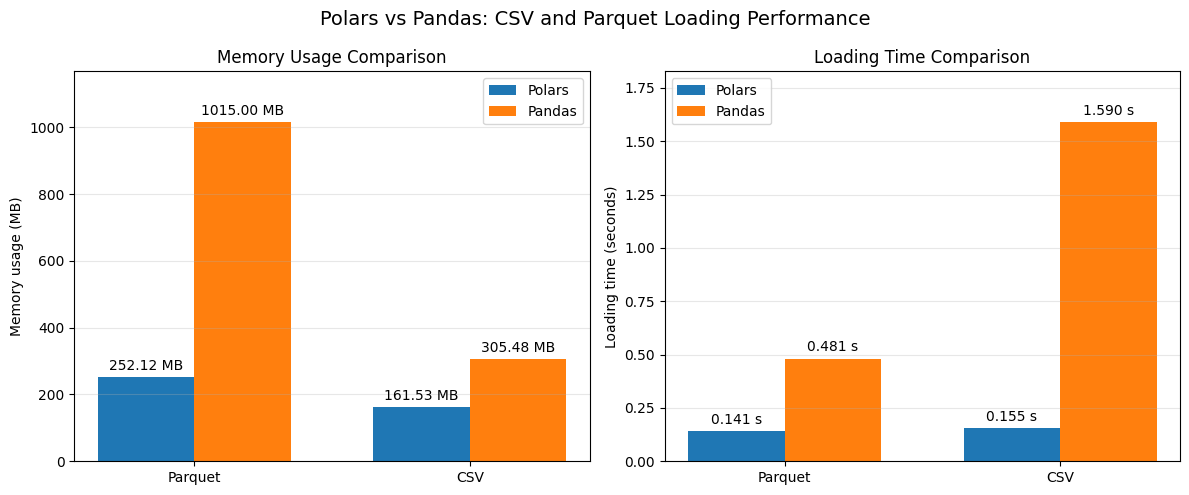

In [8]:

## labels

labels = ["Parquet", "CSV"]

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----------------------
# Exact memory values
# ----------------------
bars_pl_memory = axes[0].bar(
    x - width / 2,
    memory_usage_pl,
    width,
    label="Polars"
)

bars_pd_memory = axes[0].bar(
    x + width / 2,
    memory_usage_pd,
    width,
    label="Pandas"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Memory usage (MB)")
axes[0].set_title("Memory Usage Comparison")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Common memory scale across all memory bars
memory_limit = max(memory_usage_pl.max(), memory_usage_pd.max()) * 1.15
axes[0].set_ylim(0, memory_limit)

axes[0].bar_label(
    bars_pl_memory,
    fmt="%.2f MB",
    padding=3
)

axes[0].bar_label(
    bars_pd_memory,
    fmt="%.2f MB",
    padding=3
)

# ----------------------
# Exact time values
# ----------------------
bars_pl_time = axes[1].bar(
    x - width / 2,
    time_taken_pl,
    width,
    label="Polars"
)

bars_pd_time = axes[1].bar(
    x + width / 2,
    time_taken_pd,
    width,
    label="Pandas"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Loading time (seconds)")
axes[1].set_title("Loading Time Comparison")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Common time scale across all time bars
time_limit = max(time_taken_pl.max(), time_taken_pd.max()) * 1.15
axes[1].set_ylim(0, time_limit)

axes[1].bar_label(
    bars_pl_time,
    fmt="%.3f s",
    padding=3
)

axes[1].bar_label(
    bars_pd_time,
    fmt="%.3f s",
    padding=3
)

fig.suptitle(
    "Polars vs Pandas: CSV and Parquet Loading Performance",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Load data in the DB to start analysis


In [10]:
con = duckdb.connect("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/mobility_data_processed.duckdb")

In [11]:
# see what is in the database
con.execute("SHOW TABLES").fetchall()

[('long_od_weighted_20',),
 ('origin_time_summary',),
 ('prox_lookup',),
 ('unweighted',),
 ('weighted',)]

In [13]:
# close the db connection
con.close()


In [12]:
# export prox_lookup as parquet
prox_lookup = con.sql("SELECT * FROM prox_lookup").df()
prox_lookup.to_parquet("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/processed_mobility_tables/prox_lookup.parquet", index=False)

In [ ]:
# remove a table if it exists
con.execute("DROP TABLE IF EXISTS spatial_proximity")

In [ ]:
# open a parquet using pl in duckdb

# con.execute("CREATE TABLE IF NOT EXISTS long_od_weighted_20 AS SELECT * FROM parquet_scan('mobility_data/processed_mobility_tables/long_od_time_weighted_A_20days.parquet')")

In [ ]:
# print table
con.execute("SELECT * FROM long_od_weighted_20 LIMIT 5").df()

,norm_spatial_id_origin,origin_name,origin_type,HalfMonthIndex,date,subset_type,days_span,norm_spatial_id_destination,destination_name,destination_type,flow_type,N_depart,N_return,N_migrants,pop_observed_depart,pop_observed_return,rate_depart,rate_return,dest_label
0,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-002,Bignona,urban,urban → urban,0.000000,11.494558,0.000000,54438.22592,54438.22592,0.000000,0.000211,bignona__city_002
1,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-004,Dagana,urban,urban → urban,0.000000,0.000000,11.472756,54438.22592,54438.22592,0.000000,0.000000,dagana__city_004
2,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-005,Dahra Djoloff,urban,urban → urban,0.000000,0.000000,0.000000,54438.22592,54438.22592,0.000000,0.000000,dahra_djoloff__city_005
3,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-006,Dakar,urban,urban → urban,285.495206,218.396599,1135.802817,54438.22592,54438.22592,0.005244,0.004012,dakar__city_006
4,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-007,Darou Mousty,urban,urban → urban,0.000000,0.000000,0.000000,54438.22592,54438.22592,0.000000,0.000000,darou_mousty__city_007


### get unique pairs

In [ ]:
cdr_table = "long_od_weighted_20"

od_pairs = con.sql(f"""
SELECT DISTINCT
    norm_spatial_id_origin AS origin_id,
    norm_spatial_id_destination AS destination_id
FROM {cdr_table}
""").df()

od_pairs

,origin_id,destination_id
0,city-032,sen.12.2.4
1,city-032,sen.13.2.1
2,city-032,sen.13.2.2
3,city-032,sen.13.2.3
4,city-032,sen.3.2.2
...,...,...
22645,sen.8.1.2,sen.8.3.2
22646,city-005,sen.6.1.2
22647,city-005,sen.7.1.3
22648,city-005,sen.7.3.1


### Compute spatial proximity from spatial units

In [ ]:
units = gpd.read_parquet("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/spatial_units_with_lat_lon.parquet")

unit_id_col = "norm_id"

# Use metric CRS for Senegal
metric_crs = units.estimate_utm_crs()
# Or manually:
# metric_crs = "EPSG:32628"

units_m = units.to_crs(metric_crs).copy()

units_m["centroid"] = units_m.geometry.centroid
units_m["x"] = units_m["centroid"].x
units_m["y"] = units_m["centroid"].y

# units_m

In [ ]:
## Lookup-table

lookup = units_m[[unit_id_col, "geometry", "centroid", "x", "y"]].copy()

origin_lookup = lookup.rename(columns={
    unit_id_col: "origin_id",
    "geometry": "origin_geom",
    "centroid": "origin_centroid",
    "x": "origin_x",
    "y": "origin_y"
})

destination_lookup = lookup.rename(columns={
    unit_id_col: "destination_id",
    "geometry": "destination_geom",
    "centroid": "destination_centroid",
    "x": "destination_x",
    "y": "destination_y"
})

prox = (
    od_pairs
    .merge(origin_lookup, on="origin_id", how="left")
    .merge(destination_lookup, on="destination_id", how="left")
)

In [ ]:
# centroid distance in km

prox["centroid_distance_km"] = (
    np.sqrt(
        (prox["origin_x"] - prox["destination_x"]) ** 2
        + (prox["origin_y"] - prox["destination_y"]) ** 2
    ) / 1000
)

In [ ]:
# prox

In [ ]:
# Create aligned GeoSeries from the geometry columns
origin_geom = gpd.GeoSeries(
    prox["origin_geom"],
    index=prox.index,
    crs=metric_crs
)

destination_geom = gpd.GeoSeries(
    prox["destination_geom"],
    index=prox.index,
    crs=metric_crs
)

# repair invalid geometries
origin_geom = origin_geom.make_valid()
destination_geom = destination_geom.make_valid()

# Distance between polygon boundaries/geometries
prox["polygon_gap_km"] = (
    origin_geom.distance(destination_geom) / 1000
)

# Identify origin-destination pairs representing the same unit
prox["is_same_unit"] = (
    prox["origin_id"] == prox["destination_id"]
)

# Queen contiguity:
# polygons share either an edge or a corner,
# but their interiors do not overlap
prox["is_adjacent"] = (
    origin_geom.touches(destination_geom)
    & ~prox["is_same_unit"]
)

# shared boundary length for identifying rook neighbors
shared_boundary = origin_geom.boundary.intersection(
    destination_geom.boundary
)

prox["shared_boundary_length_m"] = shared_boundary.length

# Rook contiguity:
# polygons share an edge with non-zero length
prox["is_adjacent_rook"] = (
    (prox["shared_boundary_length_m"] > 0)
    & prox["is_adjacent"]
)

# Queen-only neighbors:
# polygons touch only at a corner
prox["is_adjacent_corner_only"] = (
    prox["is_adjacent"]
    & ~prox["is_adjacent_rook"]
)

# Display queen-adjacent units
adjacent_pairs = (
    prox.loc[
        prox["is_adjacent"],
        [
            "origin_id",
            "destination_id",
            "polygon_gap_km",
            "shared_boundary_length_m",
            "is_adjacent_rook",
            "is_adjacent_corner_only",
        ]
    ]
    .drop_duplicates()
    .sort_values(["origin_id", "destination_id"])
)

print(f"Queen-adjacent pairs found: {len(adjacent_pairs)}")
print(f"Any adjacent units: {not adjacent_pairs.empty}")

display(adjacent_pairs)

Queen-adjacent pairs found: 732
Any adjacent units: True


,origin_id,destination_id,polygon_gap_km,shared_boundary_length_m,is_adjacent_rook,is_adjacent_corner_only
8093,city-001,sen.2.1.2,0.0,13279.238444,True,False
16578,city-001,sen.2.1.3,0.0,19415.359679,True,False
2478,city-002,sen.14.1.4,0.0,43971.803629,True,False
2491,city-004,sen.10.1.1,0.0,41711.618029,True,False
5688,city-005,sen.8.2.1,0.0,8388.274055,True,False
...,...,...,...,...,...,...
3108,sen.9.3.1,sen.8.2.2,0.0,54194.519370,True,False
5949,sen.9.3.1,sen.9.1.1,0.0,47130.425840,True,False
3110,sen.9.3.1,sen.9.1.2,0.0,117959.129001,True,False
8683,sen.9.3.1,sen.9.2.1,0.0,45342.960993,True,False


Adjacent units for city-001:


,origin_id,destination_id,polygon_gap_km,shared_boundary_length_m,is_adjacent_rook,is_adjacent_corner_only
8093,city-001,sen.2.1.2,0.0,13279.238444,True,False
16578,city-001,sen.2.1.3,0.0,19415.359679,True,False
12219,sen.2.1.2,city-001,0.0,13279.238444,True,False
20801,sen.2.1.3,city-001,0.0,19415.359679,True,False


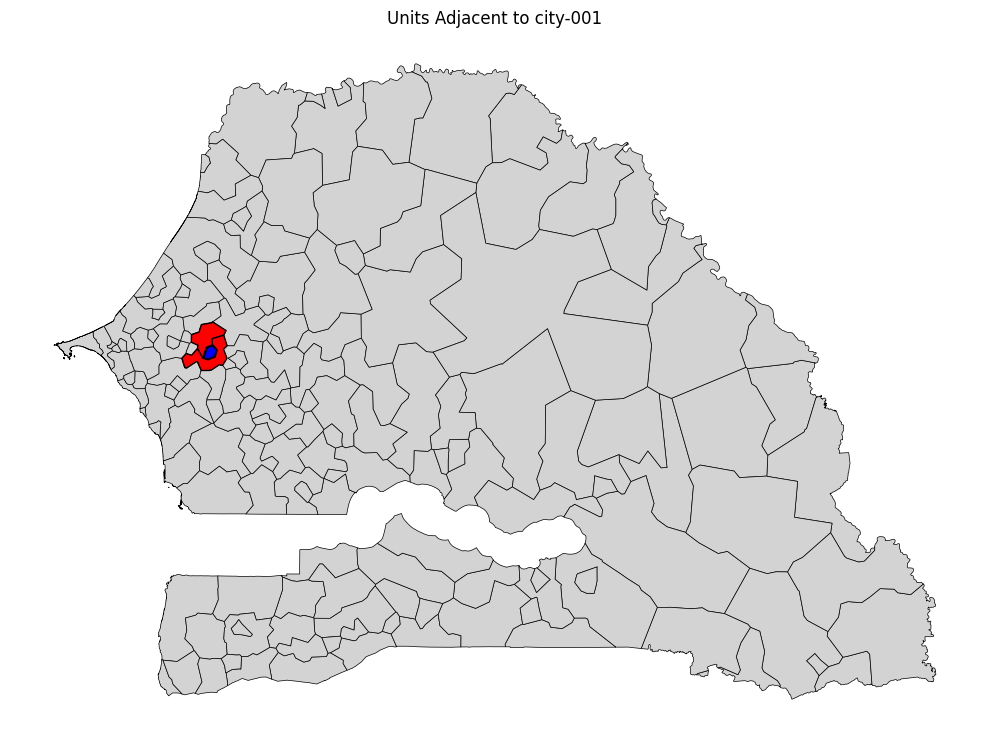

In [ ]:
target_unit = "city-001"

target_neighbors = adjacent_pairs[
    (adjacent_pairs["origin_id"] == target_unit)
    | (adjacent_pairs["destination_id"] == target_unit)
].copy()

print(f"Adjacent units for {target_unit}:")
display(target_neighbors)

# Extract the IDs on the opposite side of each adjacency pair
neighbor_ids = set(
    target_neighbors.loc[
        target_neighbors["origin_id"] == target_unit,
        "destination_id"
    ]
).union(
    target_neighbors.loc[
        target_neighbors["destination_id"] == target_unit,
        "origin_id"
    ]
)

# Select target and neighboring geometries
target_gdf = units_m[units_m[unit_id_col] == target_unit]
neighbors_gdf = units_m[units_m[unit_id_col].isin(neighbor_ids)]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

units_m.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

neighbors_gdf.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=1
)

target_gdf.plot(
    ax=ax,
    color="blue",
    edgecolor="black",
    linewidth=1.5
)

ax.set_title(f"Units Adjacent to {target_unit}")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
## distance bands

bins = [0, 25, 50, 100, 200, 400, 800, np.inf]
# chhange labels to be 1, 2, 3, 4, 5, 6, 7 with the corresponding distance bands in km as a comment next to each label

# 1: 0-25 km
# 2: 25-50 km
# 3: 50-100 km
# 4: 100-200 km
# 5: 200-400 km
# 6: 400-800 km
# 7: 800+ km
labels = [1, 2, 3, 4, 5, 6, 7]

prox["distance_band_km"] = pd.cut(
    prox["centroid_distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(str)

prox["log_distance_km"] = np.log1p(prox["centroid_distance_km"])
prox["inverse_distance"] = 1 / (1 + prox["centroid_distance_km"])

In [ ]:
prox

In [ ]:
prox["origin_distance_rank"] = (
    prox
    .sort_values(["origin_id", "centroid_distance_km"])
    .groupby("origin_id")["centroid_distance_km"]
    .rank(method="dense") ## tied ranking method, so that equal distances get the same rank
    .astype(int)
)

prox["is_top5_nearest"] = prox["origin_distance_rank"] <= 5
prox["is_top10_nearest"] = prox["origin_distance_rank"] <= 10

In [1]:
prox_lookup = prox[
    [
        "origin_id",
        "destination_id",
        "centroid_distance_km",
        "polygon_gap_km",
        "is_same_unit",
        "is_adjacent",
        "distance_band_km",
        "log_distance_km",
        "inverse_distance",
        "origin_distance_rank",
        "is_top5_nearest",
        "is_top10_nearest"
    ]
].copy()

NameError: name 'prox' is not defined

In [ ]:
prox_lookup

In [18]:
# con.register("prox_lookup", prox_lookup)
con.execute("CREATE TABLE IF NOT EXISTS prox_lookup AS SELECT * FROM prox_lookup")
cdr_with_prox_sample = con.sql(f"""
SELECT
    c.*,
    p.centroid_distance_km,
    p.polygon_gap_km,
    p.is_same_unit,
    p.is_adjacent,
    p.distance_band_km,
    p.log_distance_km,
    p.inverse_distance,
    p.origin_distance_rank,
    p.is_top5_nearest,
    p.is_top10_nearest
FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
LIMIT 100
""").df()

cdr_with_prox_sample.head()

,norm_spatial_id_origin,origin_name,origin_type,HalfMonthIndex,date,subset_type,days_span,norm_spatial_id_destination,destination_name,destination_type,...,centroid_distance_km,polygon_gap_km,is_same_unit,is_adjacent,distance_band_km,log_distance_km,inverse_distance,origin_distance_rank,is_top5_nearest,is_top10_nearest
0,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-002,Bignona,urban,...,212.402211,199.730196,False,False,5,5.363179,0.004686,92,False,False
1,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-004,Dagana,urban,...,221.003614,205.288662,False,False,5,5.402694,0.004504,96,False,False
2,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-005,Dahra Djoloff,urban,...,129.707991,114.700795,False,False,4,4.872966,0.007651,70,False,False
3,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-006,Dakar,urban,...,97.956978,75.789361,False,False,3,4.594685,0.010105,57,False,False
4,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-007,Darou Mousty,urban,...,56.601743,45.859232,False,False,3,4.053553,0.017361,29,False,False


In [19]:
distance_time = con.sql(f"""
SELECT
    c.date,
    p.distance_band_km,

    SUM(c.N_depart) AS total_depart,
    SUM(c.N_return) AS total_return,

    COUNT(*) AS n_od_time_rows,
    COUNT(CASE WHEN c.N_depart > 0 THEN 1 END) AS n_positive_depart_rows,
    COUNT(CASE WHEN c.N_return > 0 THEN 1 END) AS n_positive_return_rows

FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
WHERE p.distance_band_km IS NOT NULL
GROUP BY
    c.date,
    p.distance_band_km
ORDER BY
    c.date,
    p.distance_band_km
""").df()

distance_time

,date,distance_band_km,total_depart,total_return,n_od_time_rows,n_positive_depart_rows,n_positive_return_rows
0,2013-01-16,1,11814.895415,10660.393427,278,207,191
1,2013-01-16,2,21683.574497,19164.486066,1022,496,432
2,2013-01-16,3,28380.531436,21809.530874,2760,813,655
3,2013-01-16,4,36419.114461,24552.192900,6180,1060,796
4,2013-01-16,5,23084.514764,17804.133964,9888,1038,801
...,...,...,...,...,...,...,...
403,2015-12-01,2,21832.946638,20600.039402,1022,517,491
404,2015-12-01,3,28012.345122,23221.104429,2760,803,724
405,2015-12-01,4,29616.499199,27740.398743,6180,1010,1001
406,2015-12-01,5,22700.014950,22212.809210,9888,1083,1083


In [20]:
flow_weighted_distance = con.sql(f"""
SELECT
    c.norm_spatial_id_origin,
    c.origin_name,
    c.date,
    c.HalfMonthIndex,
    c.subset_type,
    c.days_span,

    SUM(c.N_depart) AS total_depart,
    SUM(c.N_return) AS total_return,

    CASE
        WHEN SUM(c.N_depart) > 0
        THEN SUM(c.N_depart * p.centroid_distance_km) / SUM(c.N_depart)
        ELSE NULL
    END AS flow_weighted_distance_depart_km,

    CASE
        WHEN SUM(c.N_return) > 0
        THEN SUM(c.N_return * p.centroid_distance_km) / SUM(c.N_return)
        ELSE NULL
    END AS flow_weighted_distance_return_km,

    CASE
        WHEN SUM(c.N_depart) > 0
        THEN SUM(CASE WHEN p.is_top5_nearest THEN c.N_depart ELSE 0 END) / SUM(c.N_depart)
        ELSE NULL
    END AS share_depart_top5_nearest,

    CASE
        WHEN SUM(c.N_return) > 0
        THEN SUM(CASE WHEN p.is_top5_nearest THEN c.N_return ELSE 0 END) / SUM(c.N_return)
        ELSE NULL
    END AS share_return_top5_nearest

FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
GROUP BY
    c.norm_spatial_id_origin,
    c.origin_name,
    c.date,
    c.HalfMonthIndex,
    c.subset_type,
    c.days_span
ORDER BY
    c.norm_spatial_id_origin,
    c.date
""").df()

flow_weighted_distance.head()

,norm_spatial_id_origin,origin_name,date,HalfMonthIndex,subset_type,days_span,total_depart,total_return,flow_weighted_distance_depart_km,flow_weighted_distance_return_km,share_depart_top5_nearest,share_return_top5_nearest
0,city-001,Bambey,2013-01-16,20130116,A,20days,879.325235,1356.357825,81.123091,93.212423,0.155844,0.025424
1,city-001,Bambey,2013-02-01,20130201,A,20days,811.793677,1901.985548,84.989228,91.569409,0.140845,0.048193
2,city-001,Bambey,2013-02-16,20130216,A,20days,503.696015,606.724746,106.403040,108.383055,0.090909,0.056604
3,city-001,Bambey,2013-03-01,20130301,A,20days,573.319241,905.844401,78.555665,108.496876,0.160000,0.101266
4,city-001,Bambey,2013-03-16,20130316,A,20days,677.198506,1412.082749,69.006421,84.484295,0.220339,0.154472


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# band_order = ["0-25", "25-50", "50-100", "100-200", "200-400", "400-800", "800+"]

distance_time["date"] = pd.to_datetime(distance_time["date"])
flow_weighted_distance["date"] = pd.to_datetime(flow_weighted_distance["date"])

In [22]:
distance_time

,date,distance_band_km,total_depart,total_return,n_od_time_rows,n_positive_depart_rows,n_positive_return_rows
0,2013-01-16,1,11814.895415,10660.393427,278,207,191
1,2013-01-16,2,21683.574497,19164.486066,1022,496,432
2,2013-01-16,3,28380.531436,21809.530874,2760,813,655
3,2013-01-16,4,36419.114461,24552.192900,6180,1060,796
4,2013-01-16,5,23084.514764,17804.133964,9888,1038,801
...,...,...,...,...,...,...,...
403,2015-12-01,2,21832.946638,20600.039402,1022,517,491
404,2015-12-01,3,28012.345122,23221.104429,2760,803,724
405,2015-12-01,4,29616.499199,27740.398743,6180,1010,1001
406,2015-12-01,5,22700.014950,22212.809210,9888,1083,1083


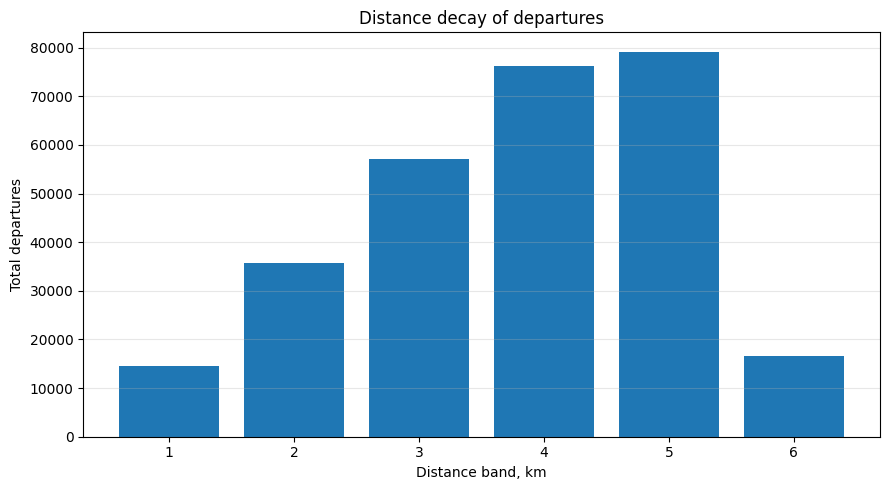

In [23]:
distance_total = (
    distance_time
    .groupby("distance_band_km", observed=True)
    .agg(
        total_depart=("total_depart", "sum"),
        total_return=("total_return", "sum"),
        positive_depart_rows=("n_positive_depart_rows", "sum"),
        positive_return_rows=("n_positive_return_rows", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.bar(distance_total["distance_band_km"], distance_total["positive_depart_rows"])
plt.xlabel("Distance band, km")
plt.ylabel("Total departures")
plt.title("Distance decay of departures")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

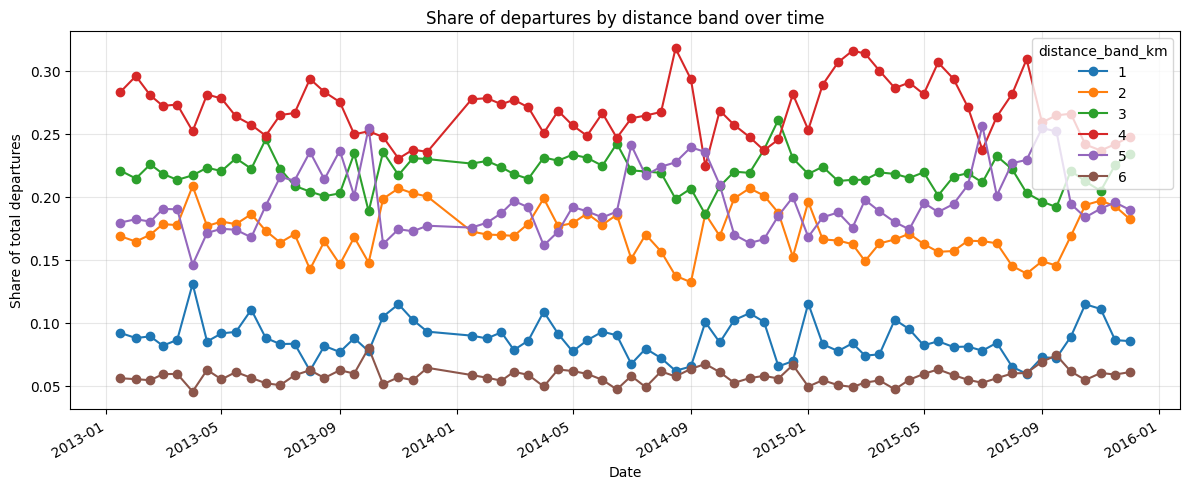

In [24]:
dt = distance_time.copy()

dt["total_depart_all_bands"] = (
    dt.groupby("date")["total_depart"].transform("sum")
)

dt["share_depart"] = np.where(
    dt["total_depart_all_bands"] > 0,
    dt["total_depart"] / dt["total_depart_all_bands"],
    np.nan
)

share_pivot = (
    dt.pivot_table(
        index="date",
        columns="distance_band_km",
        values="share_depart",
        aggfunc="sum",
        observed=True
    )
)

share_pivot.plot(figsize=(12, 5), marker="o")
plt.xlabel("Date")
plt.ylabel("Share of total departures")
plt.title("Share of departures by distance band over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

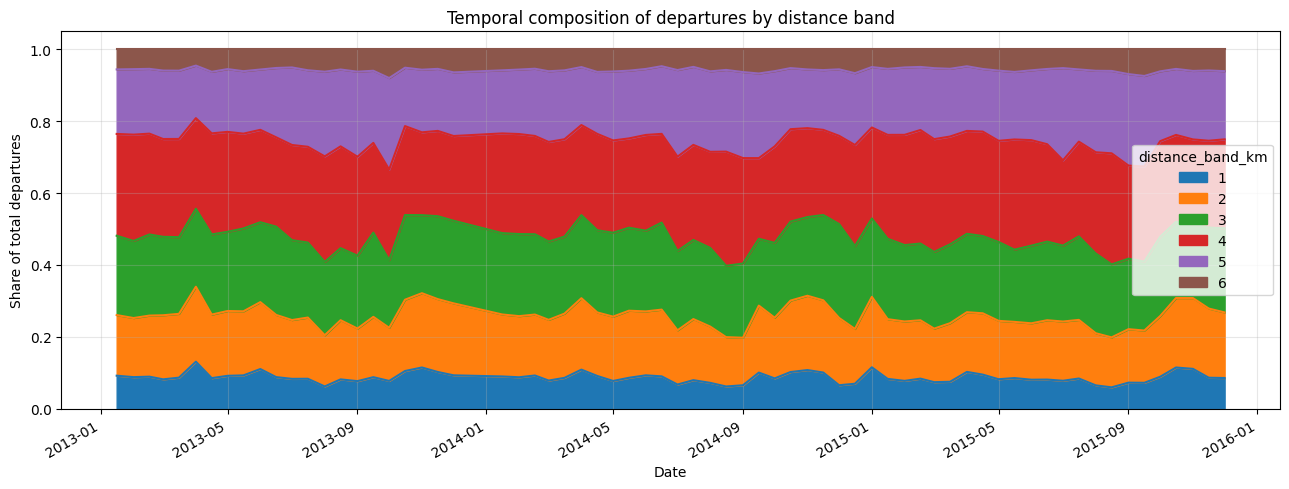

In [25]:
share_pivot.plot.area(figsize=(13, 5))
plt.xlabel("Date")
plt.ylabel("Share of total departures")
plt.title("Temporal composition of departures by distance band")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

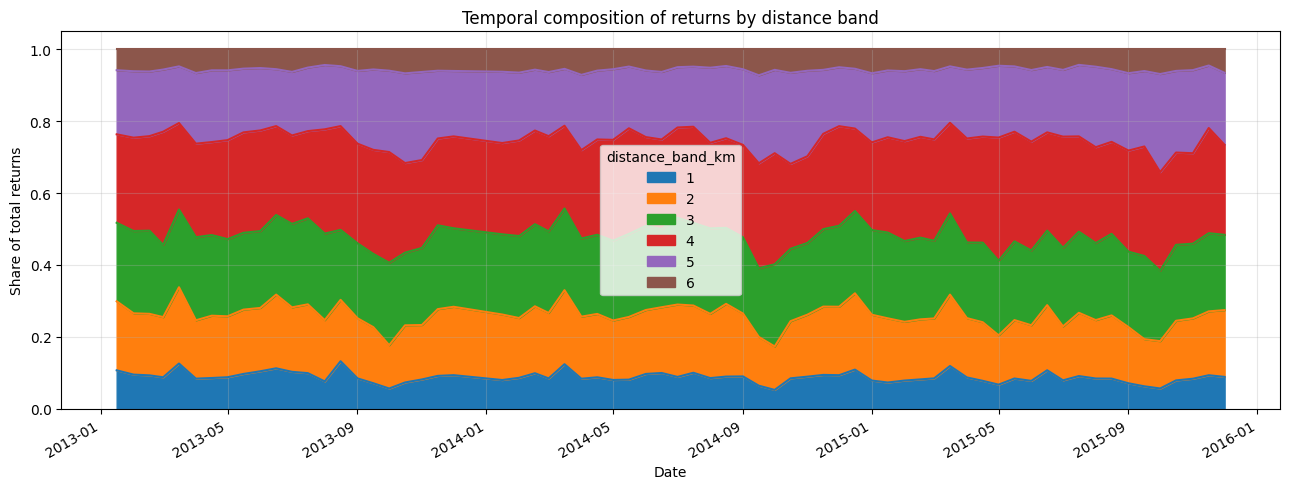

In [26]:
dt["total_return_all_bands"] = (
    dt.groupby("date")["total_return"].transform("sum")
)

dt["share_return"] = np.where(
    dt["total_return_all_bands"] > 0,
    dt["total_return"] / dt["total_return_all_bands"],
    np.nan
)

return_share_pivot = (
    dt.pivot_table(
        index="date",
        columns="distance_band_km",
        values="share_return",
        aggfunc="sum",
        observed=True
    )
    # .reindex(columns=band_order)
)

return_share_pivot.plot.area(figsize=(13, 5))
plt.xlabel("Date")
plt.ylabel("Share of total returns")
plt.title("Temporal composition of returns by distance band")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

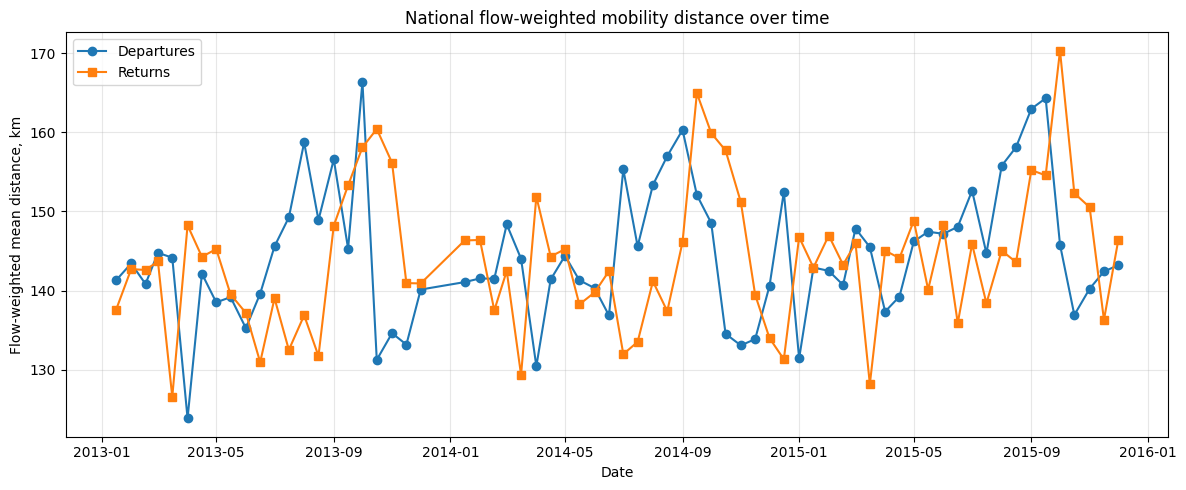

In [28]:
national_distance = con.sql(f"""
SELECT
    c.date,

    SUM(c.N_depart) AS total_depart,
    SUM(c.N_return) AS total_return,

    CASE
        WHEN SUM(c.N_depart) > 0
        THEN SUM(c.N_depart * p.centroid_distance_km) / SUM(c.N_depart)
        ELSE NULL
    END AS national_flow_weighted_distance_depart_km,

    CASE
        WHEN SUM(c.N_return) > 0
        THEN SUM(c.N_return * p.centroid_distance_km) / SUM(c.N_return)
        ELSE NULL
    END AS national_flow_weighted_distance_return_km

FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
GROUP BY c.date
ORDER BY c.date
""").df()

national_distance["date"] = pd.to_datetime(national_distance["date"])

plt.figure(figsize=(12, 5))
plt.plot(
    national_distance["date"],
    national_distance["national_flow_weighted_distance_depart_km"],
    marker="o",
    label="Departures"
)
plt.plot(
    national_distance["date"],
    national_distance["national_flow_weighted_distance_return_km"],
    marker="s",
    label="Returns"
)
plt.xlabel("Date")
plt.ylabel("Flow-weighted mean distance, km")
plt.title("National flow-weighted mobility distance over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

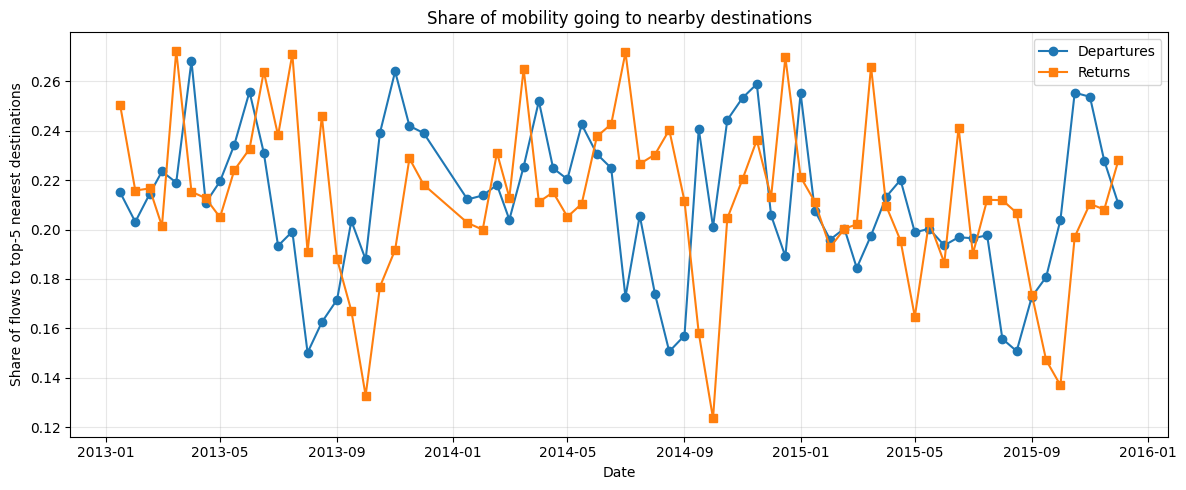

In [29]:
top5_time = con.sql(f"""
SELECT
    c.date,

    SUM(c.N_depart) AS total_depart,
    SUM(c.N_return) AS total_return,

    CASE
        WHEN SUM(c.N_depart) > 0
        THEN SUM(CASE WHEN p.is_top5_nearest THEN c.N_depart ELSE 0 END) / SUM(c.N_depart)
        ELSE NULL
    END AS share_depart_top5_nearest,

    CASE
        WHEN SUM(c.N_return) > 0
        THEN SUM(CASE WHEN p.is_top5_nearest THEN c.N_return ELSE 0 END) / SUM(c.N_return)
        ELSE NULL
    END AS share_return_top5_nearest

FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
GROUP BY c.date
ORDER BY c.date
""").df()

top5_time["date"] = pd.to_datetime(top5_time["date"])

plt.figure(figsize=(12, 5))
plt.plot(top5_time["date"], top5_time["share_depart_top5_nearest"], marker="o", label="Departures")
plt.plot(top5_time["date"], top5_time["share_return_top5_nearest"], marker="s", label="Returns")
plt.xlabel("Date")
plt.ylabel("Share of flows to top-5 nearest destinations")
plt.title("Share of mobility going to nearby destinations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

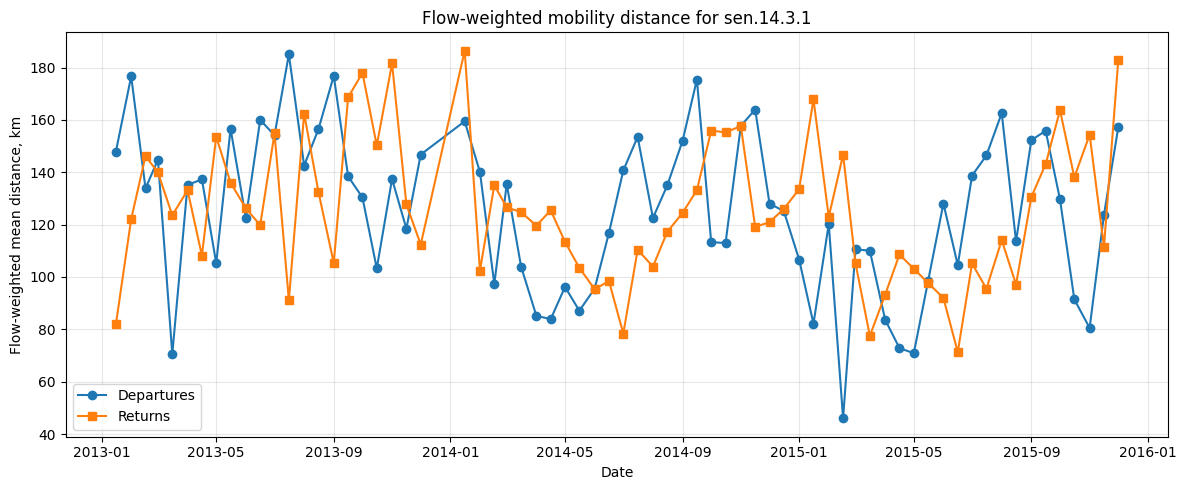

In [30]:
unit_id = "sen.14.3.1"

unit_ts = flow_weighted_distance[
    flow_weighted_distance["norm_spatial_id_origin"] == unit_id
].copy()

plt.figure(figsize=(12, 5))
plt.plot(unit_ts["date"], unit_ts["flow_weighted_distance_depart_km"], marker="o", label="Departures")
plt.plot(unit_ts["date"], unit_ts["flow_weighted_distance_return_km"], marker="s", label="Returns")
plt.xlabel("Date")
plt.ylabel("Flow-weighted mean distance, km")
plt.title(f"Flow-weighted mobility distance for {unit_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

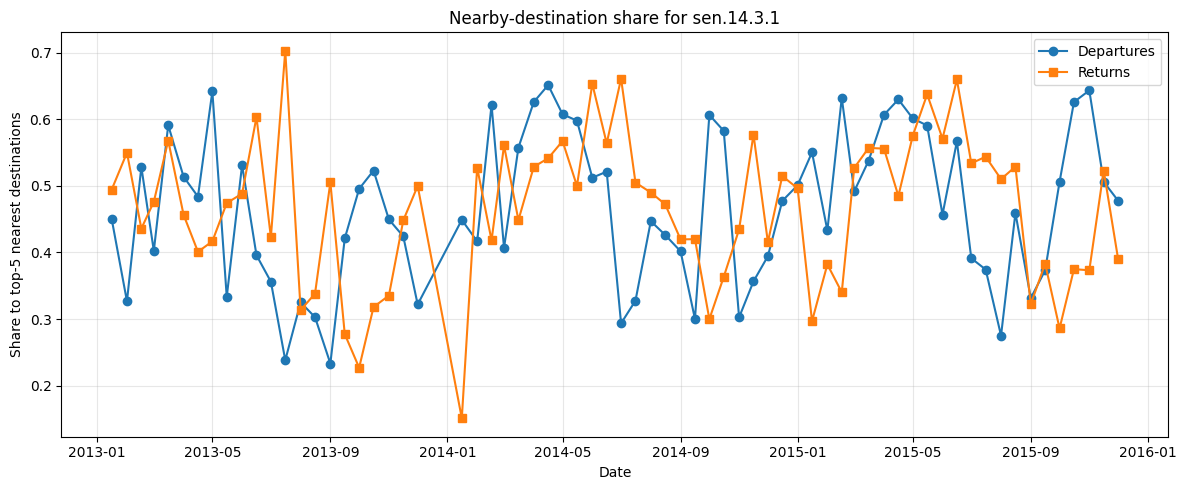

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(unit_ts["date"], unit_ts["share_depart_top5_nearest"], marker="o", label="Departures")
plt.plot(unit_ts["date"], unit_ts["share_return_top5_nearest"], marker="s", label="Returns")
plt.xlabel("Date")
plt.ylabel("Share to top-5 nearest destinations")
plt.title(f"Nearby-destination share for {unit_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

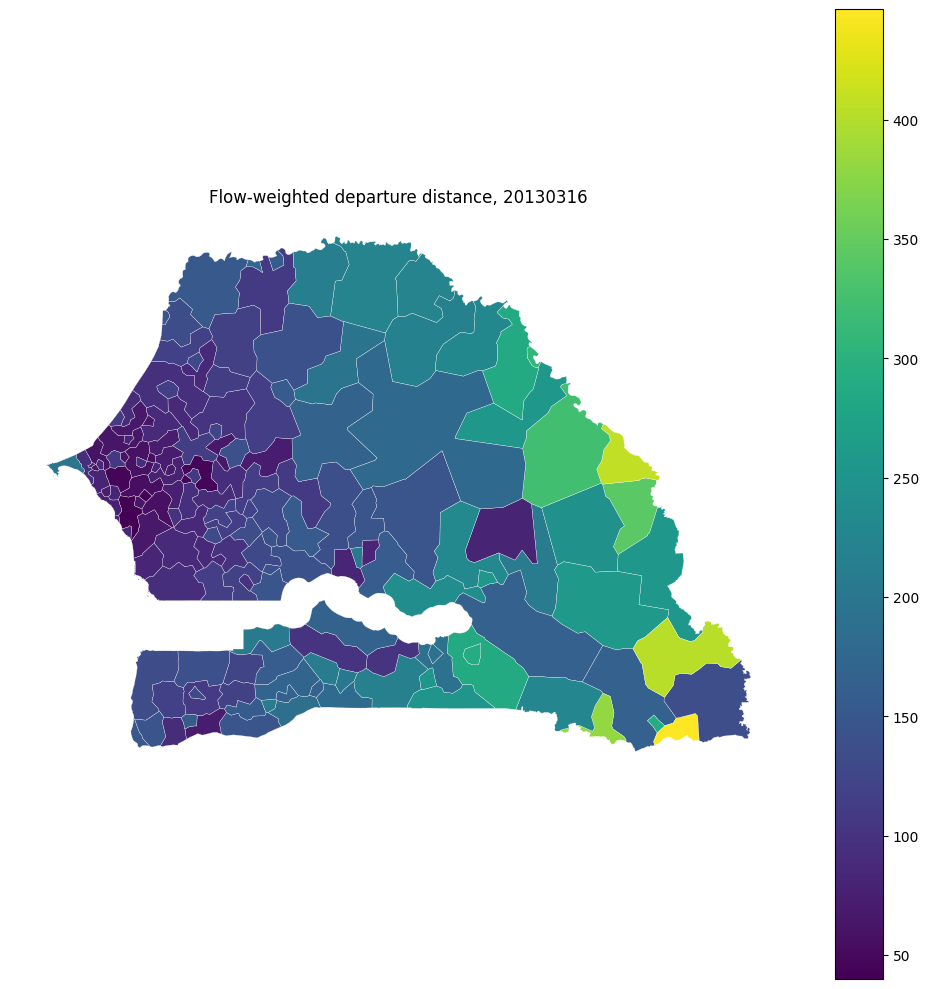

In [32]:
import geopandas as gpd

# units = gpd.read_parquet("spatial_units.geoparquet")

hm = 20130316

map_df = units.merge(
    flow_weighted_distance[
        flow_weighted_distance["HalfMonthIndex"] == hm
    ],
    left_on="norm_id",
    right_on="norm_spatial_id_origin",
    how="left"
)

fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="flow_weighted_distance_depart_km",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No flow / no data"}
)

ax.set_title(f"Flow-weighted departure distance, {hm}")
ax.axis("off")
plt.tight_layout()
plt.show()

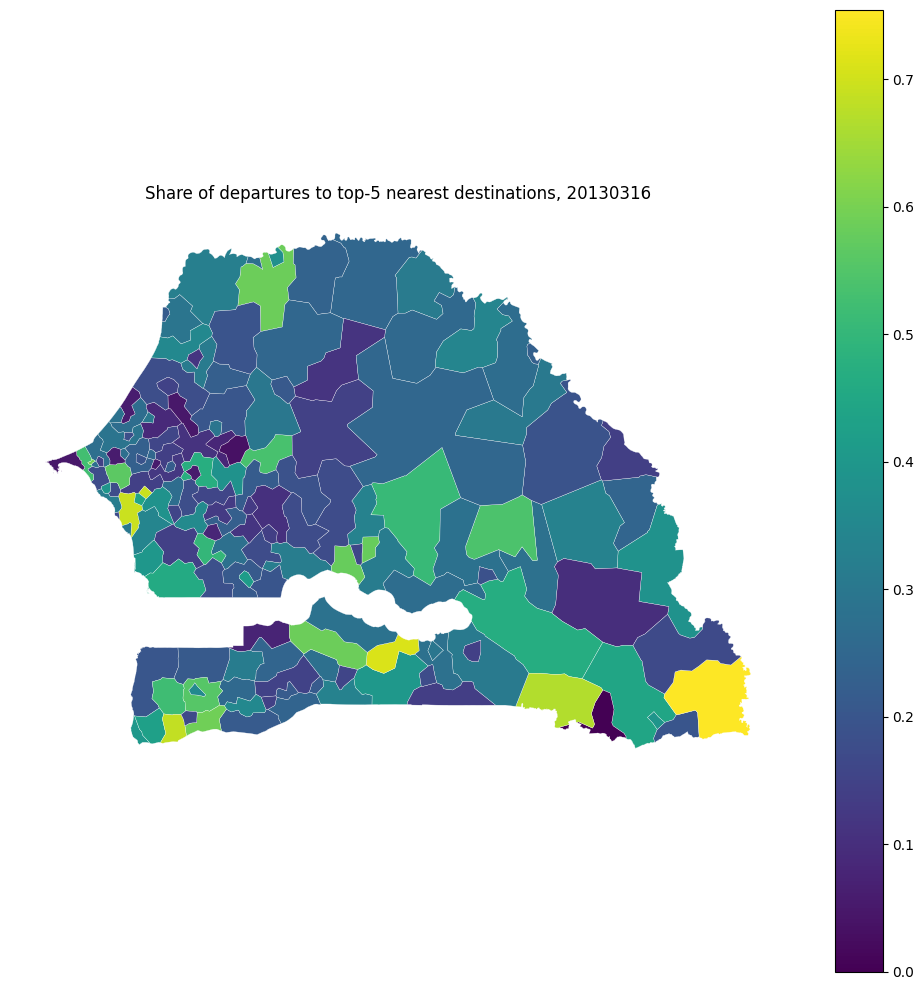

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="share_depart_top5_nearest",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No flow / no data"}
)

ax.set_title(f"Share of departures to top-5 nearest destinations, {hm}")
ax.axis("off")
plt.tight_layout()
plt.show()

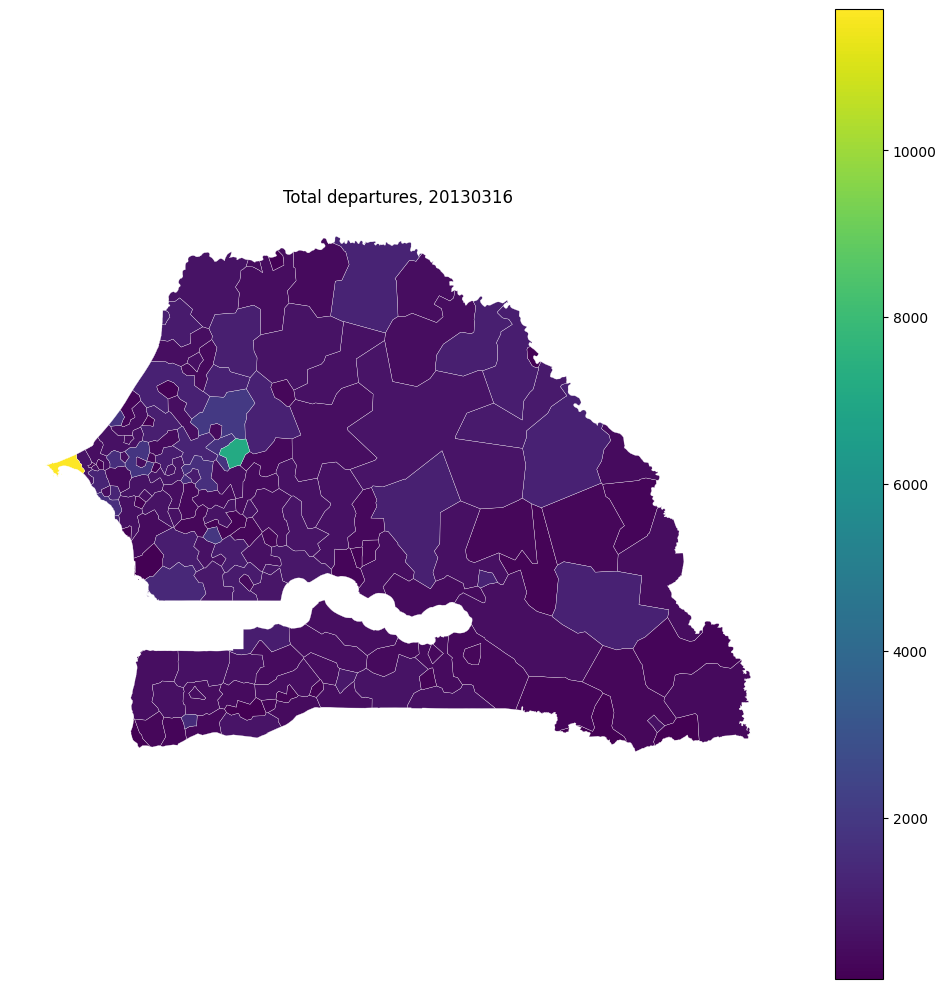

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="total_depart",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No flow / no data"}
)

ax.set_title(f"Total departures, {hm}")
ax.axis("off")
plt.tight_layout()
plt.show()

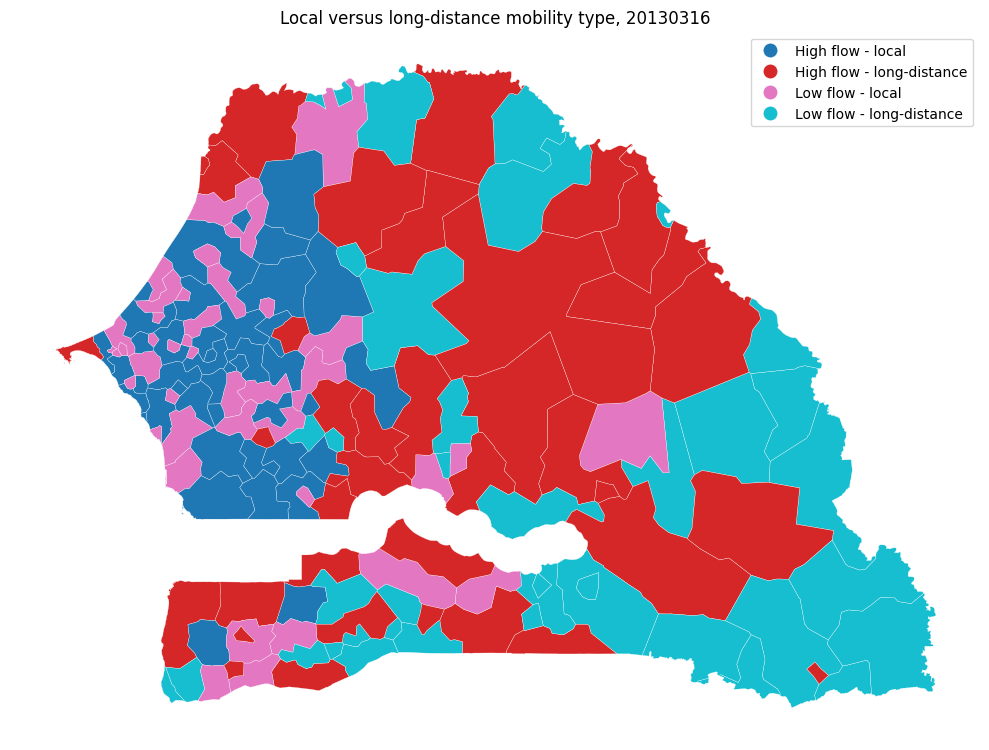

In [35]:
map_df["mobility_distance_type"] = np.select(
    [
        (map_df["total_depart"] > map_df["total_depart"].median()) &
        (map_df["flow_weighted_distance_depart_km"] <= map_df["flow_weighted_distance_depart_km"].median()),

        (map_df["total_depart"] > map_df["total_depart"].median()) &
        (map_df["flow_weighted_distance_depart_km"] > map_df["flow_weighted_distance_depart_km"].median()),

        (map_df["total_depart"] <= map_df["total_depart"].median()) &
        (map_df["flow_weighted_distance_depart_km"] <= map_df["flow_weighted_distance_depart_km"].median()),

        (map_df["total_depart"] <= map_df["total_depart"].median()) &
        (map_df["flow_weighted_distance_depart_km"] > map_df["flow_weighted_distance_depart_km"].median())
    ],
    [
        "High flow - local",
        "High flow - long-distance",
        "Low flow - local",
        "Low flow - long-distance"
    ],
    default="No data"
)

fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="mobility_distance_type",
    categorical=True,
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax
)

ax.set_title(f"Local versus long-distance mobility type, {hm}")
ax.axis("off")
plt.tight_layout()
plt.show()

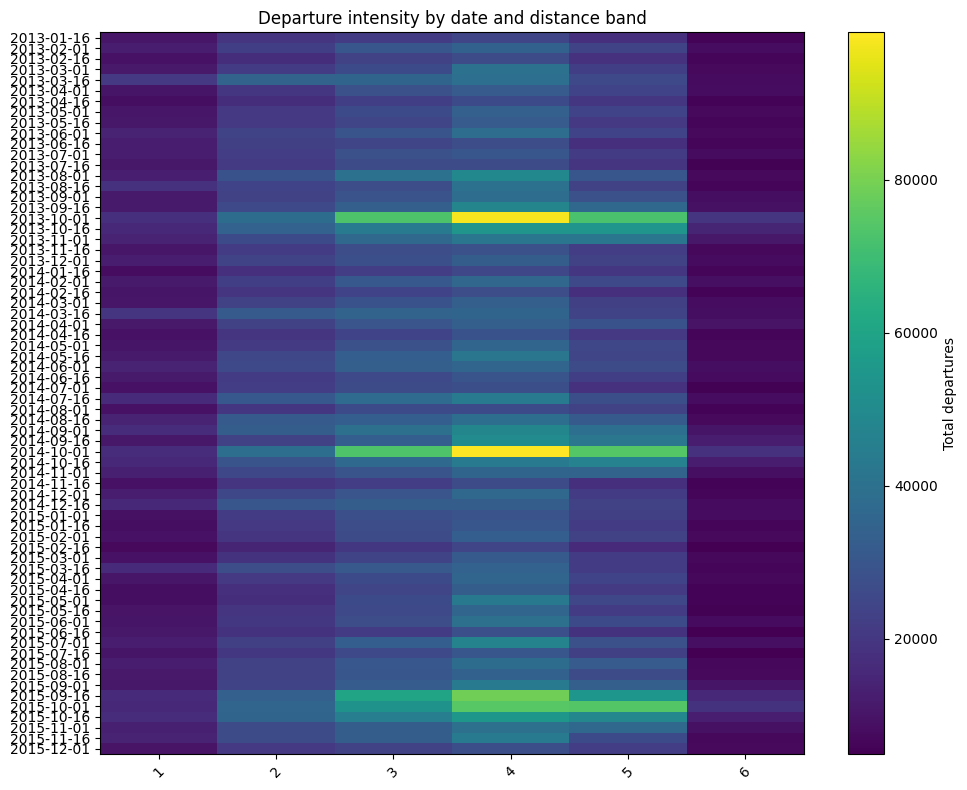

In [36]:
heat = (
    distance_time
    .pivot_table(
        index="date",
        columns="distance_band_km",
        values="total_return",
        aggfunc="sum",
        observed=True
    )
)

plt.figure(figsize=(10, 8))
plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index.strftime("%Y-%m-%d"))
plt.colorbar(label="Total departures")
plt.title("Departure intensity by date and distance band")
plt.tight_layout()
plt.show()

### Model Approach

For the statistical test, start with this logic:

N_depart_ijt = f(distance_ij, adjacency_ij, origin_i, destination_j, time_t)

A good model specification:

N_depart_ijt ~ log_distance_ij + is_adjacent_ij + origin fixed effects + destination fixed effects + date fixed effects

Then a stronger spatiotemporal version:

N_depart_ijt ~ log_distance_ij + is_adjacent_ij + climate_origin_it
             + log_distance_ij × climate_origin_it
             + origin fixed effects + destination fixed effects + date fixed effects

Interpretation:

negative log_distance coefficient = closer destinations receive more flows
positive adjacency coefficient = neighbouring units have stronger flows
interaction with climate = climate stress changes whether moves are local or long-distance

In [48]:
model_df = con.sql(f"""
SELECT
    c.N_depart,
    p.log_distance_km,
    p.is_adjacent,
    c.norm_spatial_id_origin,
    c.norm_spatial_id_destination,
    c.date
FROM {cdr_table} c
LEFT JOIN prox_lookup p
    ON  c.norm_spatial_id_origin = p.origin_id
    AND c.norm_spatial_id_destination = p.destination_id
""").df()

In [49]:
model_df.head()

,N_depart,log_distance_km,is_adjacent,norm_spatial_id_origin,norm_spatial_id_destination,date
0,0.000000,3.393248,False,sen.13.2.2,city-042,2013-11-01
1,0.000000,5.553446,False,sen.13.2.2,city-043,2013-11-01
2,0.000000,5.890471,False,sen.13.2.2,city-046,2013-11-01
3,0.000000,3.442777,False,sen.13.2.2,city-047,2013-11-01
4,429.999531,2.903018,True,sen.13.2.2,city-048,2013-11-01


In [50]:
## basic poisson regression model with log_distance_km and is_adjacent as predictors for N_depart

import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="""
        N_depart ~ log_distance_km + is_adjacent
    """,
    data=model_df,
    family=sm.families.Poisson()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               N_depart   No. Observations:              1540200
Model:                            GLM   Df Residuals:                  1540197
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4940e+07
Date:                Mon, 03 Aug 2026   Deviance:                   4.8619e+07
Time:                        09:55:51   Pearson chi2:                 5.41e+08
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9868
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4403    

### Interpretation

- **`log_distance_km = -0.7350`**
  - Negative sign means: **larger distance is associated with fewer departures**.
  - In a Poisson model, the multiplicative effect is:
    ```python
    np.exp(-0.7350)  # ≈ 0.48
    ```
  - So a 1-unit increase in `log_distance_km` is associated with about **52% fewer departures**, holding adjacency constant.

- **`is_adjacent[T.True] = 0.7099`**
  - Positive sign means: **adjacent units have more departures** than non-adjacent ones.
  - Multiplicative effect:
    ```python
    np.exp(0.7099)  # ≈ 2.03
    ```
  - So adjacent pairs have about **2.0x higher expected departures**, holding distance constant.

- **Intercept = 5.4403**
  - Baseline log expected count when predictors are at reference values.
  - Not usually interpreted substantively here.

### Fit
- Very large sample: **1,540,200 observations**
- Both predictors are **highly statistically significant** (`p < 0.001`)
- The model shows a strong distance decay pattern and a strong adjacency effect.

### Important caution
- The **pseudo R-squared is very high**, but this is common in large count models and does not mean the model is fully sufficient.
- This is only a **simple bivariate specification**. It does not control for:
  - origin fixed effects
  - destination fixed effects
  - date effects
  - zero inflation / overdispersion

### Short conclusion
The results suggest:

- **mobility decreases with distance**
- **neighboring areas exchange more flows**
- the pattern is **highly significant**

In [51]:
model_df_sample = model_df.sample(min(len(model_df), 500000), random_state=42)

model_fe = smf.glm(
    formula="""
        N_depart ~ log_distance_km + is_adjacent
        + C(norm_spatial_id_origin)
        + C(norm_spatial_id_destination)
        + C(date)
    """,
    data=model_df_sample,
    family=sm.families.Poisson()
).fit()

print(model_fe.summary())

# For the full dataset, I would use R fixest::fepois() or Stata ppmlhdfe, because high-dimensional fixed effects will be heavy in plain Python.

                 Generalized Linear Model Regression Results                  
Dep. Variable:               N_depart   No. Observations:               500000
Model:                            GLM   Df Residuals:                   499630
Model Family:                 Poisson   Df Model:                          369
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6282e+06
Date:                Mon, 03 Aug 2026   Deviance:                   4.8476e+06
Time:                        09:59:38   Pearson chi2:                 1.47e+07
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------